## SWE - Nahom Gebreyohannis, Niranjana Parashar, Gulnara Amangeldiyeva


In [1]:
#import cell

import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import pandas as pd

In [2]:
#temp-volt data 

v0 = -0.01 #+- 0.01 mV
t0 = 0 #°C

v1 = 1.49 #mV
t1 = 40.1 #°C

v2 = 2.47 #mV 
t2 = 68.6 #°C

C:\Users\nahom\AppData\Local\Temp\ipykernel_78976\3868755272.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov= sp.optimize.curve_fit(tempvolt, t, v_1)


-4.4030887437944504e-05 0.039172122376785266 -0.01


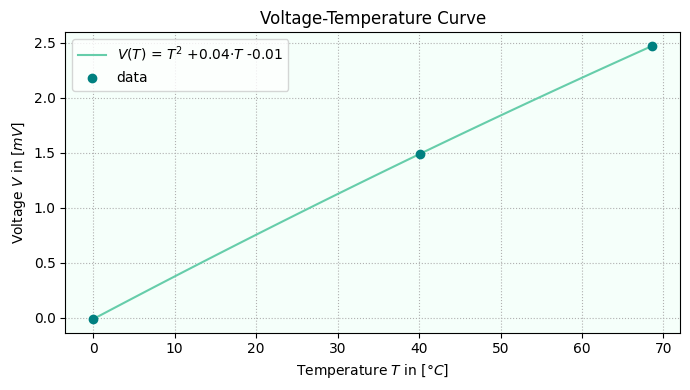

In [3]:
#temp-volt plot

v_1 = [v0, v1, v2]
t = [t0, t1, t2]
t_cf = np.linspace(min(t), max(t), 101)

def tempvolt(t_c, a, b, c):
    return a*t_c**2+b*t_c+c
popt, pcov= sp.optimize.curve_fit(tempvolt, t, v_1)
acf, bcf, ccf = popt
vcf = tempvolt(t_cf, acf, bcf, ccf)

plt.figure(figsize=(7,4))
cflabel= f'$V(T)$ = $T^2$ {bcf:+.2f}$\\cdot T$ {ccf:+.2f}'
plt.plot(t_cf, vcf, color='mediumaquamarine', label=cflabel)
plt.plot(t, v_1, 'o', color='teal', label='data')
plt.grid(ls=':')
plt.title('Voltage-Temperature Curve')
plt.ylabel('Voltage $V$ in $[mV]$')
plt.xlabel('Temperature $T$ in $[°C]$')
plt.legend()
ax = plt.gca()
ax.set_facecolor("mintcream")
plt.tight_layout()
plt.savefig('SWE_TV')
print(acf, bcf, ccf)

In [4]:
#temp-volt table 

Tv_tabel = pd.DataFrame([[t0, (t0+273.15), v0],
                         [t1, (t1+273.15), v1],
                         [t2, (t2+273.15), v2]],
                       columns=['Temperature in $°C$', 'Temperature in $K$', 'Voltage in $mV$'])
Tv_tabel = Tv_tabel.set_index(['Temperature in $°C$'])

Tv_tabel

,Temperature in $K$,Voltage in $mV$
Temperature in $°C$,,
0.0,273.15,-0.01
40.1,313.25,1.49
68.6,341.75,2.47


In [5]:
#voltage-time data

v_start = 1.07 #mV
T_start = 69.8 #°C
uv = 6.44 #V
i_start = 1.819 
i_end = 1.805 
I = (i_start+i_end)/2

#intervals of 40s
v = np.array([1.07, 1.30, 1.53, 1.75, 1.97, 2.15, 2.32, 2.52, 2.68, 2.82, 2.96, 3.03, 3.06, 3.10, 3.13, 3.14, 3.16, 3.20, 3.20, 3.24, 3.27, 3.31, 3.32, 3.35, 3.35, 3.38, 3.39, 3.40, 3.44, 3.44, 3.47, 3.51, 3.50, 3.52, 3.54, 3.55, 3.58, 3.62, 3.66, 3.70, 3.75, 3.80, 3.86, 3.92, 4.01, 4.11, 4.21, 4.31, 4.42, 4.49])

time = []
x=0
for i in range(len(v)):
    time.append(x)
    x = x+40
#time = [round(x) for x in time]

In [6]:
#voltage-time table

vt_table = pd.DataFrame([time,
                        v.tolist()],
                       index=['time in $s$', 'Voltage in $V$'])

#transposed table:
#vt_table = vt_table.transpose()
#vt_table = vt_table.set_index(['time in $s$'])

vt_table

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
time in $s$,0.00,40.0,80.00,120.00,160.00,200.00,240.00,280.00,320.00,360.00,...,1600.00,1640.0,1680.00,1720.00,1760.00,1800.00,1840.00,1880.00,1920.00,1960.00
Voltage in $V$,1.07,1.3,1.53,1.75,1.97,2.15,2.32,2.52,2.68,2.82,...,3.75,3.8,3.86,3.92,4.01,4.11,4.21,4.31,4.42,4.49


In [8]:
#temp-time melting point avergage

Tcelsius = (np.sqrt(4*acf*(v-ccf)+bcf**2)-bcf)/(2*acf)
mp = sum(Tcelsius[14:-14])/22
mp

np.float64(96.36076900434271)

np.float64(96.99538315186737)

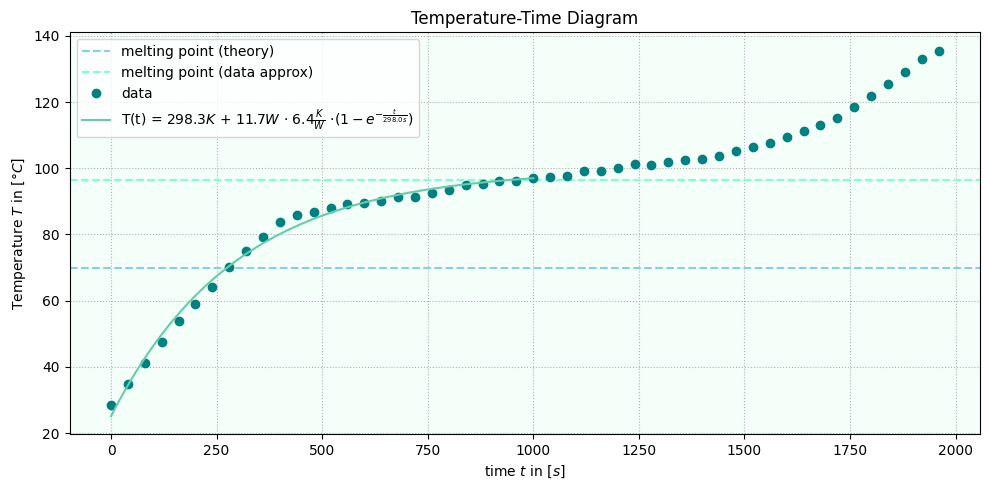

In [9]:
#temp-time plot

T = Tcelsius+273.15
T_part =  T[0:26]
time_part = time[0:26]
timecf = np.linspace(min(time_part), max(time_part), 201)
P = uv*I

def temptime(time_part, Tz, R, C):
    return Tz + R*P*(1 - np.exp(-time_part/(R*C)))
popt, pcov = sp.optimize.curve_fit(temptime, time_part, T_part)
Tzcf, Rcf, Ccf = popt
Tcf = temptime(timecf, Tzcf, Rcf, Ccf) - 273.15
tau = Rcf*Ccf

plt.figure(figsize=(10,5))
reglabel = f'T(t) = {Tzcf:.1f}$K$ + {P:.1f}$W$ $\\cdot$ {Rcf:.1f}$\\frac{{K}}{{W}}$ $\\cdot (1 - e^{{-\\frac{{t}}{{{tau:.1f}s}}}}$)'
plt.axhline(70, 0, 1, ls='--', color='skyblue', label='melting point (theory)')
plt.axhline(mp, 0, 1, ls='--', color='aquamarine', label='melting point (data approx)')
plt.plot(time, Tcelsius, 'o', color='teal', label='data')
plt.plot(timecf, Tcf, color='mediumaquamarine', label=reglabel)
plt.grid(ls=':')
plt.title('Temperature-Time Diagram')
plt.xlabel('time $t$ in $[s]$')
plt.ylabel('Temperature $T$ in $[°C]$')
plt.legend()
plt.gca().set_facecolor("mintcream")
plt.tight_layout()
plt.savefig('SWE_Tt')
max(Tcf)

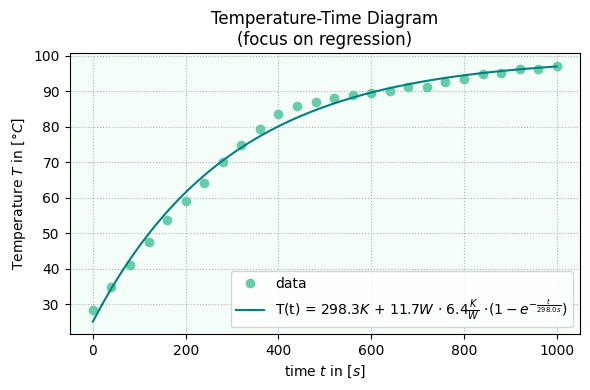

In [10]:
#temp-time plot  (with regression focus)

plt.figure(figsize=(6,4))
plt.plot(time_part, T_part-273.15, 'o', color='mediumaquamarine', label='data')
reglabel = f'T(t) = {Tzcf:.1f}$K$ + {P:.1f}$W$ $\\cdot$ {Rcf:.1f}$\\frac{{K}}{{W}}$ $\\cdot (1 - e^{{-\\frac{{t}}{{{tau:.1f}s}}}}$)'
plt.plot(timecf, Tcf, color='teal', label=reglabel)
plt.grid(ls=':')
plt.title('''Temperature-Time Diagram
(focus on regression)''')
plt.xlabel('time $t$ in $[s]$')
plt.ylabel('Temperature $T$ in $[°C]$')
plt.legend()
ax = plt.gca()
ax.set_facecolor("mintcream")
plt.tight_layout()
plt.savefig('SWE_Tt_focus')

In [11]:
#temp-time table

Tt_table = pd.DataFrame([time,
                        Tcelsius.round(2),
                        T.round(2)],
                       index=['time in $s$', 'Temperature in $°C$', 'Temperature in $K$'])

#transposed table:
#Tt_table = Tt_table.transpose()
#Tt_table = Tt_table.set_index(['time in $s$'])

Tt_table

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
time in $s$,0.00,40.00,80.00,120.00,160.00,200.00,240.00,280.00,320.00,360.00,...,1600.00,1640.00,1680.00,1720.00,1760.00,1800.00,1840.00,1880.00,1920.00,1960.00
Temperature in $°C$,28.48,34.80,41.22,47.46,53.80,59.06,64.10,70.11,74.99,79.32,...,109.45,111.15,113.20,115.26,118.37,121.87,125.41,128.98,132.96,135.52
Temperature in $K$,301.63,307.95,314.37,320.61,326.95,332.21,337.25,343.26,348.14,352.47,...,382.60,384.30,386.35,388.41,391.52,395.02,398.56,402.13,406.11,408.67
